In [15]:
import pandas as pd

df = pd.read_csv("cleaned_financial_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (3440, 6)


,text,sentiment,text_length,cleaned_text,sentiment_encoded,cleaned_length
0,"According to Gran , the company has no plans t...",neutral,127,according gran company no plan move production...,1,78
1,With the new production plant the company woul...,positive,206,new production plant company would increase ca...,2,157
2,"For the last quarter of 2010 , Componenta 's n...",positive,193,last quarter 2010 componenta net sale doubled ...,2,123
3,"In the third quarter of 2010 , net sales incre...",positive,125,third quarter 2010 net sale increased 52 % eur...,2,88
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive,122,operating profit rose eur 131 mn eur 87 mn cor...,2,95


In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(df["sentiment"])

print("Classes:", label_encoder.classes_)

Classes: ['negative' 'neutral' 'positive']


In [17]:
from sklearn.model_selection import train_test_split

X = df["cleaned_text"]
y = df["sentiment_encoded"]

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Testing size:", X_test.shape)

Training size: (2408,)
Validation size: (516,)
Testing size: (516,)


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [29]:
print("TF-IDF Shape (Training Set):", X_train_tfidf.shape)
print("TF-IDF Shape (Validation Set):", X_val_tfidf.shape)
print("TF-IDF Shape (Test Set):", X_test_tfidf.shape)

TF-IDF Shape (Training Set): (2408, 10000)
TF-IDF Shape (Validation Set): (516, 10000)
TF-IDF Shape (Test Set): (516, 10000)


In [19]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_tfidf, y_train)

log_pred = log_model.predict(X_test_tfidf)

In [20]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight="balanced")
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

In [27]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("🔹 Cross-Validation (5-Fold) Results")

# Logistic Regression CV
log_cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Accuracy:", log_cv_scores)
print("Logistic Regression CV Mean:", np.mean(log_cv_scores))


# SVM CV
svm_cv_scores = cross_val_score(
    LinearSVC(class_weight="balanced"),
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("\nSVM CV Accuracy:", svm_cv_scores)
print("SVM CV Mean:", np.mean(svm_cv_scores))

🔹 Cross-Validation (5-Fold) Results
Logistic Regression CV Accuracy: [0.78215768 0.79253112 0.81742739 0.78586279 0.7962578 ]
Logistic Regression CV Mean: 0.7948473529386393

SVM CV Accuracy: [0.81120332 0.81742739 0.84024896 0.82120582 0.81704782]
SVM CV Mean: 0.8214266612606862


In [21]:
# Validation Evaluation

from sklearn.metrics import accuracy_score

val_pred_log = log_model.predict(X_val_tfidf)
val_pred_svm = svm_model.predict(X_val_tfidf)

print("Validation Accuracy (Logistic):", accuracy_score(y_val, val_pred_log))
print("Validation Accuracy (SVM):", accuracy_score(y_val, val_pred_svm))

Validation Accuracy (Logistic): 0.8062015503875969
Validation Accuracy (SVM): 0.813953488372093


In [22]:
from sklearn.metrics import classification_report, accuracy_score

print("🔹 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

print("\n🔹 SVM Results")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

🔹 Logistic Regression Results
Accuracy: 0.7868217054263565
              precision    recall  f1-score   support

           0       0.74      0.59      0.65        63
           1       0.85      0.89      0.87       320
           2       0.65      0.64      0.64       133

    accuracy                           0.79       516
   macro avg       0.75      0.70      0.72       516
weighted avg       0.78      0.79      0.78       516


🔹 SVM Results
Accuracy: 0.8003875968992248
              precision    recall  f1-score   support

           0       0.80      0.57      0.67        63
           1       0.85      0.90      0.87       320
           2       0.68      0.66      0.67       133

    accuracy                           0.80       516
   macro avg       0.77      0.71      0.74       516
weighted avg       0.80      0.80      0.80       516



Logistic Regression Weighted F1: 0.7837146507135423
SVM Weighted F1: 0.7961671689241835


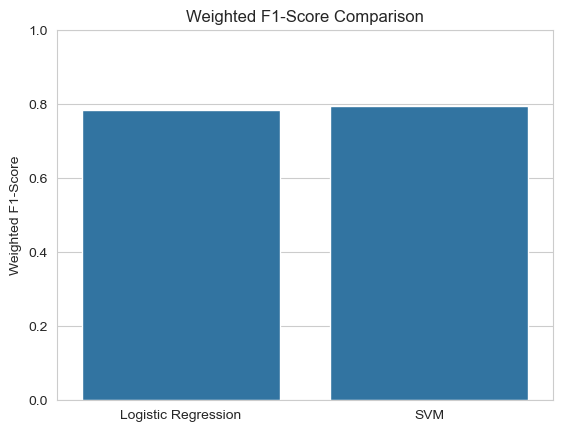

In [28]:
from sklearn.metrics import f1_score

# Compute weighted F1 scores
log_f1 = f1_score(y_test, log_pred, average="weighted")
svm_f1 = f1_score(y_test, svm_pred, average="weighted")

print("Logistic Regression Weighted F1:", log_f1)
print("SVM Weighted F1:", svm_f1)

# Plot comparison
plt.figure()
sns.barplot(
    x=["Logistic Regression", "SVM"],
    y=[log_f1, svm_f1]
)
plt.title("Weighted F1-Score Comparison")
plt.ylabel("Weighted F1-Score")
plt.ylim(0,1)
plt.show()

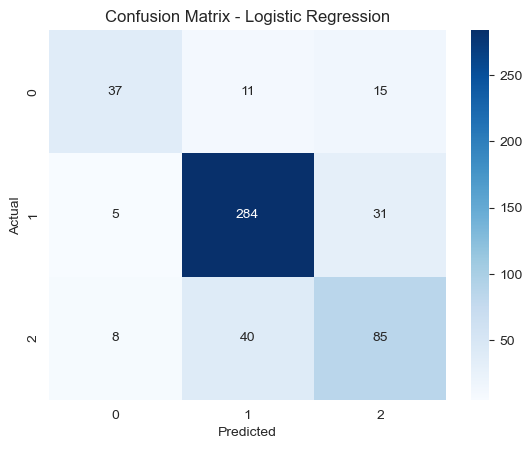

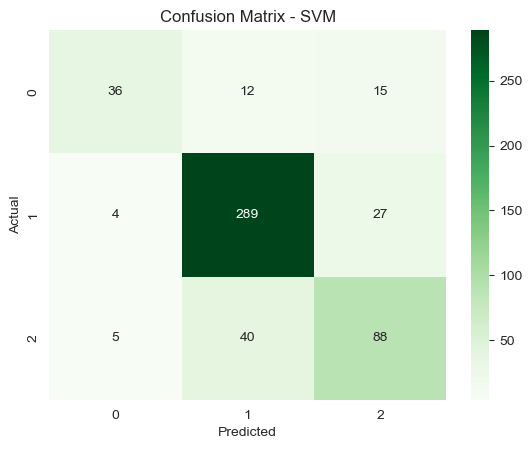

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_style("whitegrid")

# Logistic Regression
cm_log = confusion_matrix(y_test, log_pred)

plt.figure()
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SVM
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

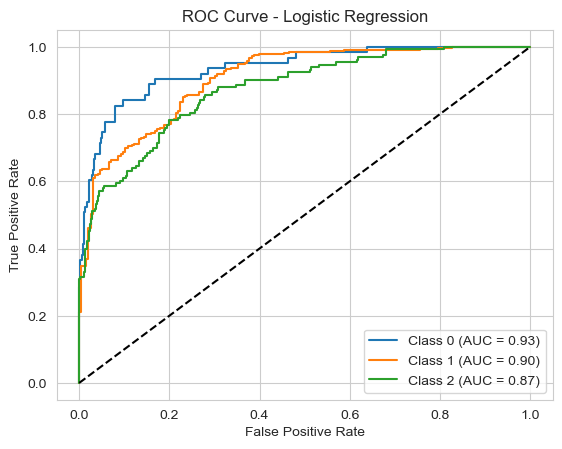

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Binarize labels
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Logistic Regression probabilities
log_probs = log_model.predict_proba(X_test_tfidf)

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], log_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

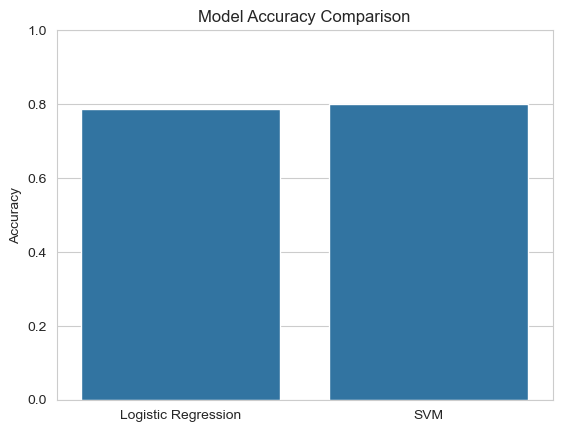

In [25]:
log_acc = accuracy_score(y_test, log_pred)
svm_acc = accuracy_score(y_test, svm_pred)

plt.figure()
sns.barplot(x=["Logistic Regression", "SVM"], y=[log_acc, svm_acc])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

In [26]:
import pickle

with open("financial_model.pkl", "wb") as f:
    pickle.dump(log_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("All files saved successfully.")

All files saved successfully.
